# General Exploration of the Student AI Consumption Dataset

## Notebook Overview
This walkthrough examines the student AI consumption dataset to understand satisfaction, session behavior, and adoption patterns. We'll progressively explore summary statistics, distributions, categorical differences, relationships between metrics, temporal dynamics, and re-use behavior before wrapping with key takeaways.

## Setup
Import core analysis libraries and apply plotting aesthetics for consistent visuals.

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Shared aesthetics for plots
BASE_PALETTE_NAME = "rocket"
palette_discrete = sns.color_palette(BASE_PALETTE_NAME, n_colors=10)
palette_continuous = sns.color_palette(BASE_PALETTE_NAME, as_cmap=True)

sns.set_style("whitegrid")
sns.set_palette(palette_discrete)
plt.rcParams['figure.figsize'] = (14, 6)

## Data Overview
Load the raw usage log and inspect structure, missingness, and summary statistics to ground later visuals.

In [24]:
# Load the dataset and inspect core structure
df = pd.read_csv('../data/AI_usage_data.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Summary:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nDescriptive Statistics (numeric columns):')
print(df.describe())

print('\nSample Rows:')
print(df.head())

Dataset Shape: (9551, 13)

Column Summary:
Discipline                    object
FinalOutcome                  object
Sum of SatisfactionRating    float64
Year                           int64
Quarter                       object
Month                         object
Day                            int64
Sum of SessionLengthMin      float64
StudentLevel                  object
TaskType                      object
Sum of TotalPrompts            int64
UsedAgain                       bool
Sum of AI_AssistanceLevel      int64
dtype: object

Missing Values:
Discipline                   0
FinalOutcome                 0
Sum of SatisfactionRating    0
Year                         0
Quarter                      0
Month                        0
Day                          0
Sum of SessionLengthMin      0
StudentLevel                 0
TaskType                     0
Sum of TotalPrompts          0
UsedAgain                    0
Sum of AI_AssistanceLevel    0
dtype: int64

Descriptive Statistics (nume

### Quick Observations
The dataset spans multiple disciplines, student levels, and task types with satisfaction, session duration, prompts, and AI assistance scores captured per interaction. No missing values were detected, making the table ready for visualization-driven exploration.

## Distribution of Usage Metrics
Evaluate how satisfaction, session length, prompts, and requested assistance levels are distributed to spot skewness, outliers, or dominant behaviors.

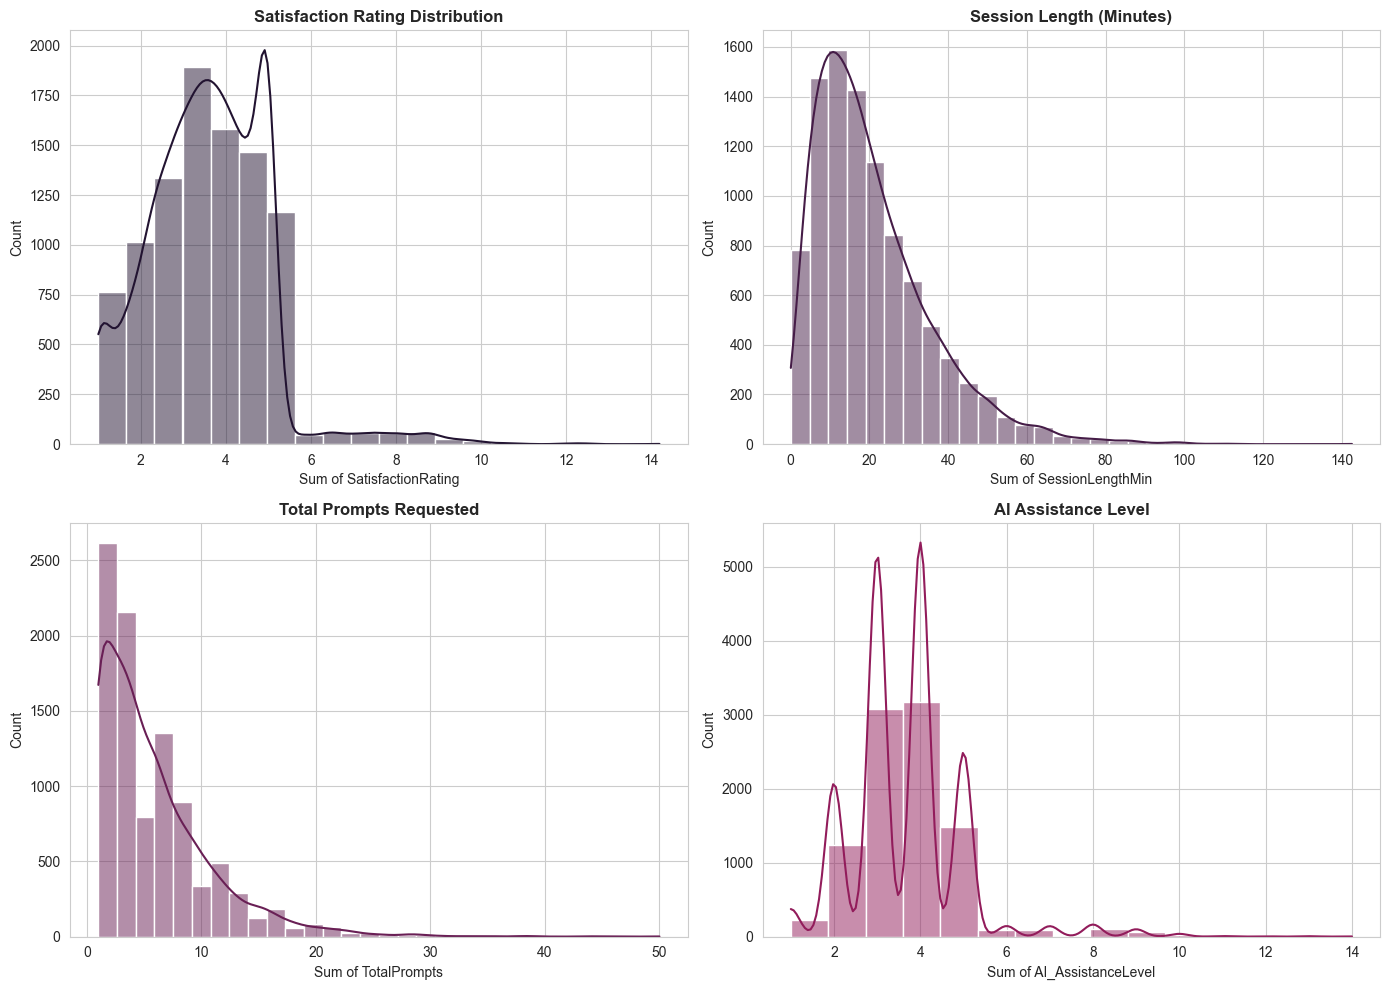

Numerical Feature Summary:
                                mean        std   min    50%     max
Sum of SatisfactionRating   3.578453   1.395056  1.00   3.60   14.20
Sum of SessionLengthMin    20.779465  14.912980  0.03  17.24  142.63
Sum of TotalPrompts         5.871113   4.914689  1.00   4.00   50.00
Sum of AI_AssistanceLevel   3.643074   1.288704  1.00   4.00   14.00


In [25]:
# Visualize distributions for key quantitative metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='Sum of SatisfactionRating', kde=True, ax=axes[0, 0], bins=20, color=palette_discrete[0])
axes[0, 0].set_title('Satisfaction Rating Distribution', fontsize=12, fontweight='bold')

sns.histplot(data=df, x='Sum of SessionLengthMin', kde=True, ax=axes[0, 1], bins=30, color=palette_discrete[1])
axes[0, 1].set_title('Session Length (Minutes)', fontsize=12, fontweight='bold')

sns.histplot(data=df, x='Sum of TotalPrompts', kde=True, ax=axes[1, 0], bins=30, color=palette_discrete[2])
axes[1, 0].set_title('Total Prompts Requested', fontsize=12, fontweight='bold')

sns.histplot(data=df, x='Sum of AI_AssistanceLevel', kde=True, ax=axes[1, 1], bins=15, color=palette_discrete[3])
axes[1, 1].set_title('AI Assistance Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('Numerical Feature Summary:')
print(df[['Sum of SatisfactionRating', 'Sum of SessionLengthMin', 'Sum of TotalPrompts', 'Sum of AI_AssistanceLevel']].describe().T[['mean', 'std', 'min', '50%', 'max']])

## Categorical Insights
Examine how usage volume is distributed across disciplines, student levels, task types, and final outcomes to understand who is relying on AI support the most.

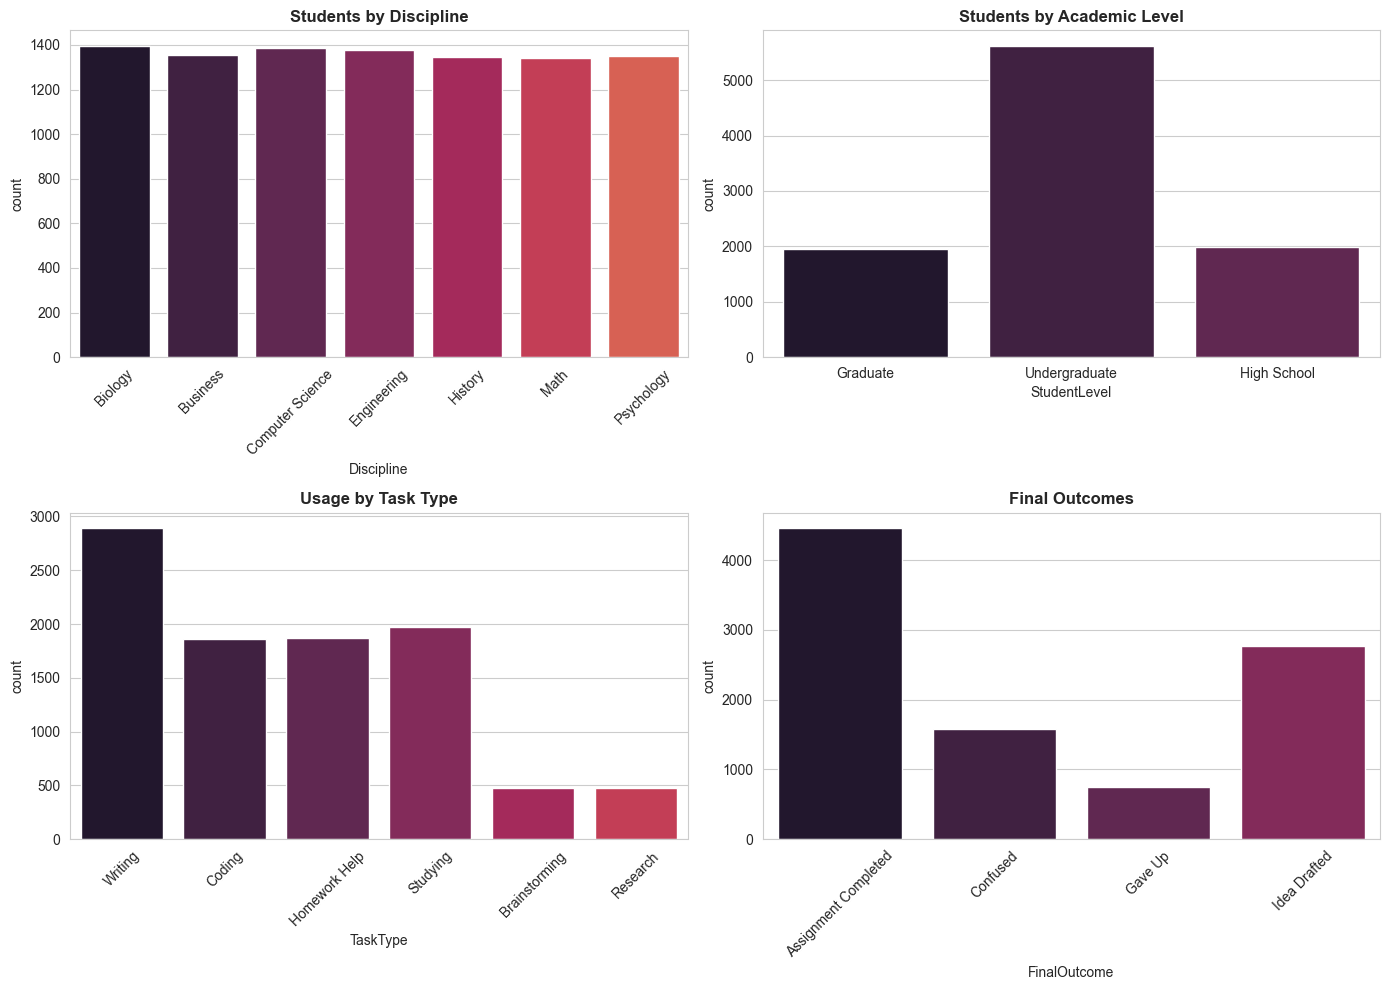


Category Counts:
Discipline      7
StudentLevel    3
TaskType        6
FinalOutcome    4
dtype: int64


In [26]:
# Compare counts across categorical dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='Discipline', ax=axes[0, 0], palette=palette_discrete)
axes[0, 0].set_title('Students by Discipline', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='StudentLevel', ax=axes[0, 1], palette=palette_discrete)
axes[0, 1].set_title('Students by Academic Level', fontsize=12, fontweight='bold')

sns.countplot(data=df, x='TaskType', ax=axes[1, 0], palette=palette_discrete)
axes[1, 0].set_title('Usage by Task Type', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='FinalOutcome', ax=axes[1, 1], palette=palette_discrete)
axes[1, 1].set_title('Final Outcomes', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nCategory Counts:')
print(df[['Discipline', 'StudentLevel', 'TaskType', 'FinalOutcome']].nunique())

## Satisfaction Drivers
Analyze how satisfaction varies by student level and task type to highlight where AI support resonates most.

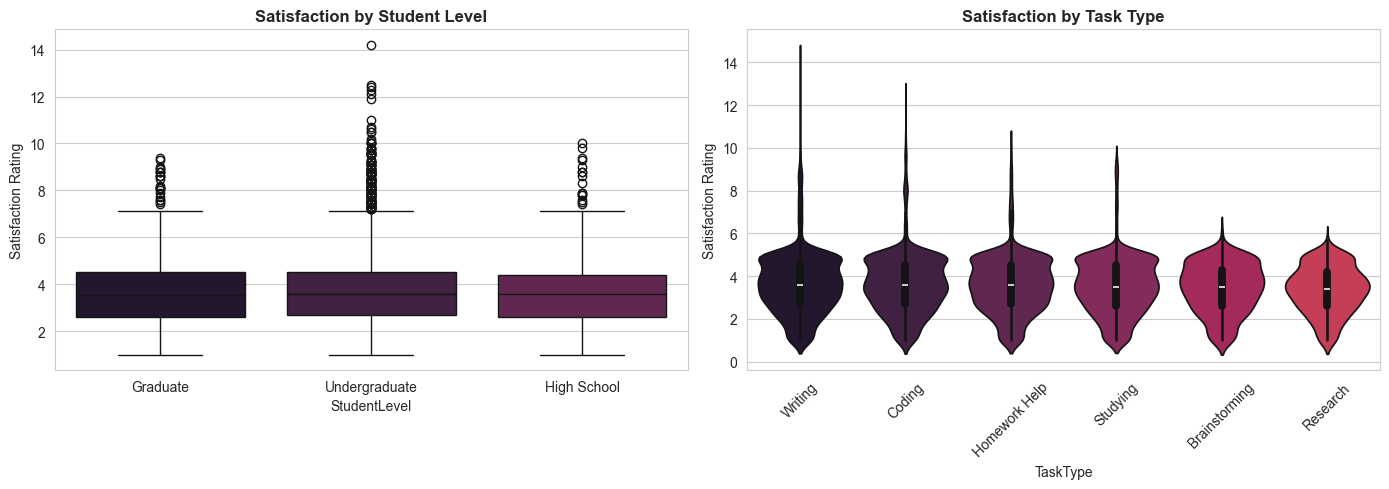

Average Satisfaction by Student Level:
                   mean       std  count
StudentLevel                            
Graduate       3.501540  1.276691   1948
High School    3.497081  1.249363   1987
Undergraduate  3.633921  1.478285   5616

Average Satisfaction by Task Type:
                   mean       std  count
TaskType                                
Brainstorming  3.412025  1.150312    474
Coding         3.610188  1.412074   1865
Homework Help  3.589156  1.366138   1872
Research       3.345684  1.090135    475
Studying       3.520781  1.346445   1973
Writing        3.655913  1.505009   2892


In [27]:
# Satisfaction patterns across student segments and task types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='StudentLevel', y='Sum of SatisfactionRating', ax=axes[0], palette=palette_discrete)
axes[0].set_title('Satisfaction by Student Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Satisfaction Rating')

sns.violinplot(data=df, x='TaskType', y='Sum of SatisfactionRating', ax=axes[1], palette=palette_discrete)
axes[1].set_title('Satisfaction by Task Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Satisfaction Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Average Satisfaction by Student Level:')
print(df.groupby('StudentLevel')['Sum of SatisfactionRating'].agg(['mean', 'std', 'count']))

print('\nAverage Satisfaction by Task Type:')
print(df.groupby('TaskType')['Sum of SatisfactionRating'].agg(['mean', 'std', 'count']))

## Correlation Structure
Inspect how quantitative measures co-vary to spot reinforcing or competing dynamics between satisfaction, time invested, prompts, and assistance levels.

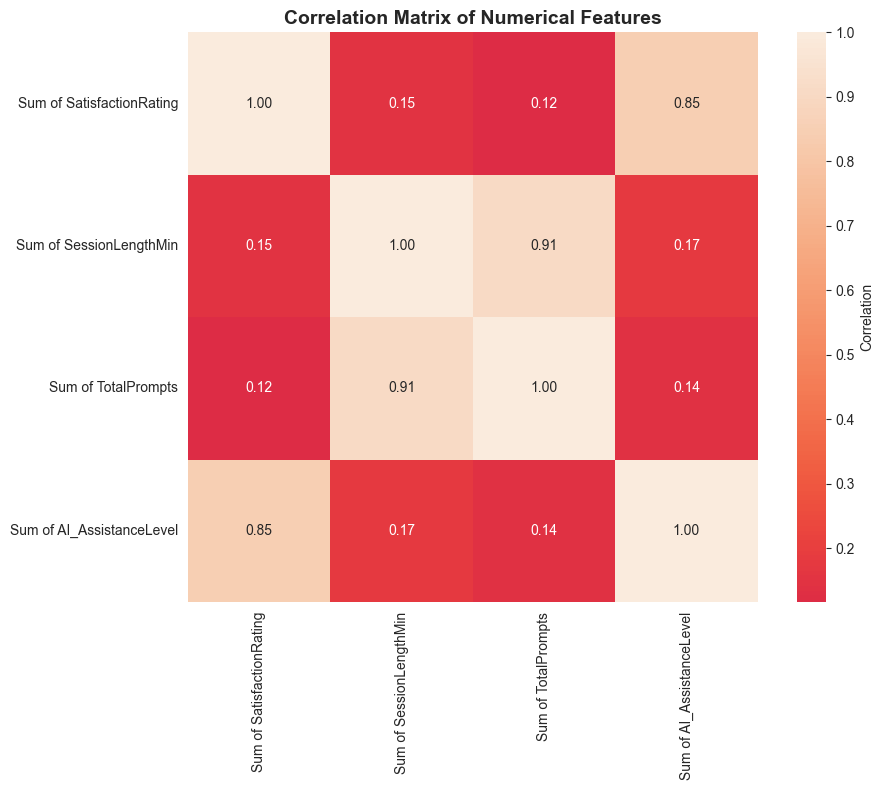

Correlation Matrix:
                           Sum of SatisfactionRating  Sum of SessionLengthMin  \
Sum of SatisfactionRating                   1.000000                 0.149527   
Sum of SessionLengthMin                     0.149527                 1.000000   
Sum of TotalPrompts                         0.116640                 0.907688   
Sum of AI_AssistanceLevel                   0.848013                 0.174481   

                           Sum of TotalPrompts  Sum of AI_AssistanceLevel  
Sum of SatisfactionRating             0.116640                   0.848013  
Sum of SessionLengthMin               0.907688                   0.174481  
Sum of TotalPrompts                   1.000000                   0.138192  
Sum of AI_AssistanceLevel             0.138192                   1.000000  


In [28]:
# Correlation heatmap for numerical features
numerical_cols = ['Sum of SatisfactionRating', 'Sum of SessionLengthMin',
                  'Sum of TotalPrompts', 'Sum of AI_AssistanceLevel']

plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=palette_continuous, center=0,
            cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix)

### Correlation Takeaways
Use the heatmap to note which metrics move together. Weak associations suggest satisfaction is influenced more by categorical context than raw usage volume, while moderate ties between prompts and assistance hint at deeper support requests.

## Workload Patterns by Task Type
Understand how engagement depth (time and prompt volume) shifts across different kinds of tasks students tackle with AI.

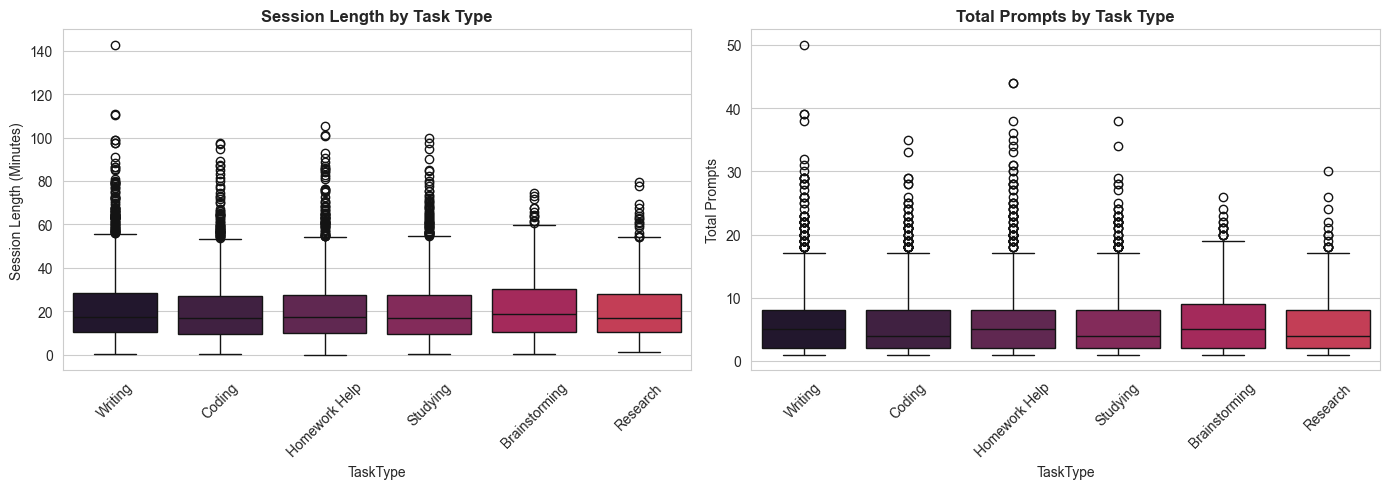


Session Duration by Task Type:
                    mean  median        std
TaskType                                   
Brainstorming  22.056899  18.945  15.293997
Coding         20.334048  16.970  14.487962
Homework Help  20.867260  17.220  15.377727
Research       20.452968  16.950  14.157641
Studying       20.375099  17.110  14.505488
Writing        21.130000  17.465  15.197679

Prompts by Task Type:
                   mean  median       std
TaskType                                 
Brainstorming  6.297468     5.0  5.206326
Coding         5.776408     4.0  4.806545
Homework Help  5.958333     5.0  5.299917
Research       5.726316     4.0  4.573917
Studying       5.716168     4.0  4.647899
Writing        5.935339     5.0  4.904093


In [29]:
# Session Length and Prompts by Task Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='TaskType', y='Sum of SessionLengthMin', ax=axes[0], palette=palette_discrete)
axes[0].set_title('Session Length by Task Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Session Length (Minutes)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='TaskType', y='Sum of TotalPrompts', ax=axes[1], palette=palette_discrete)
axes[1].set_title('Total Prompts by Task Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Prompts')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSession Duration by Task Type:")
print(df.groupby('TaskType')['Sum of SessionLengthMin'].agg(['mean', 'median', 'std']))
print("\nPrompts by Task Type:")
print(df.groupby('TaskType')['Sum of TotalPrompts'].agg(['mean', 'median', 'std']))

## Cross-Metric Relationships
Plot pairwise relationships between satisfaction, session length, prompts, and assistance level while highlighting key categorical dimensions.

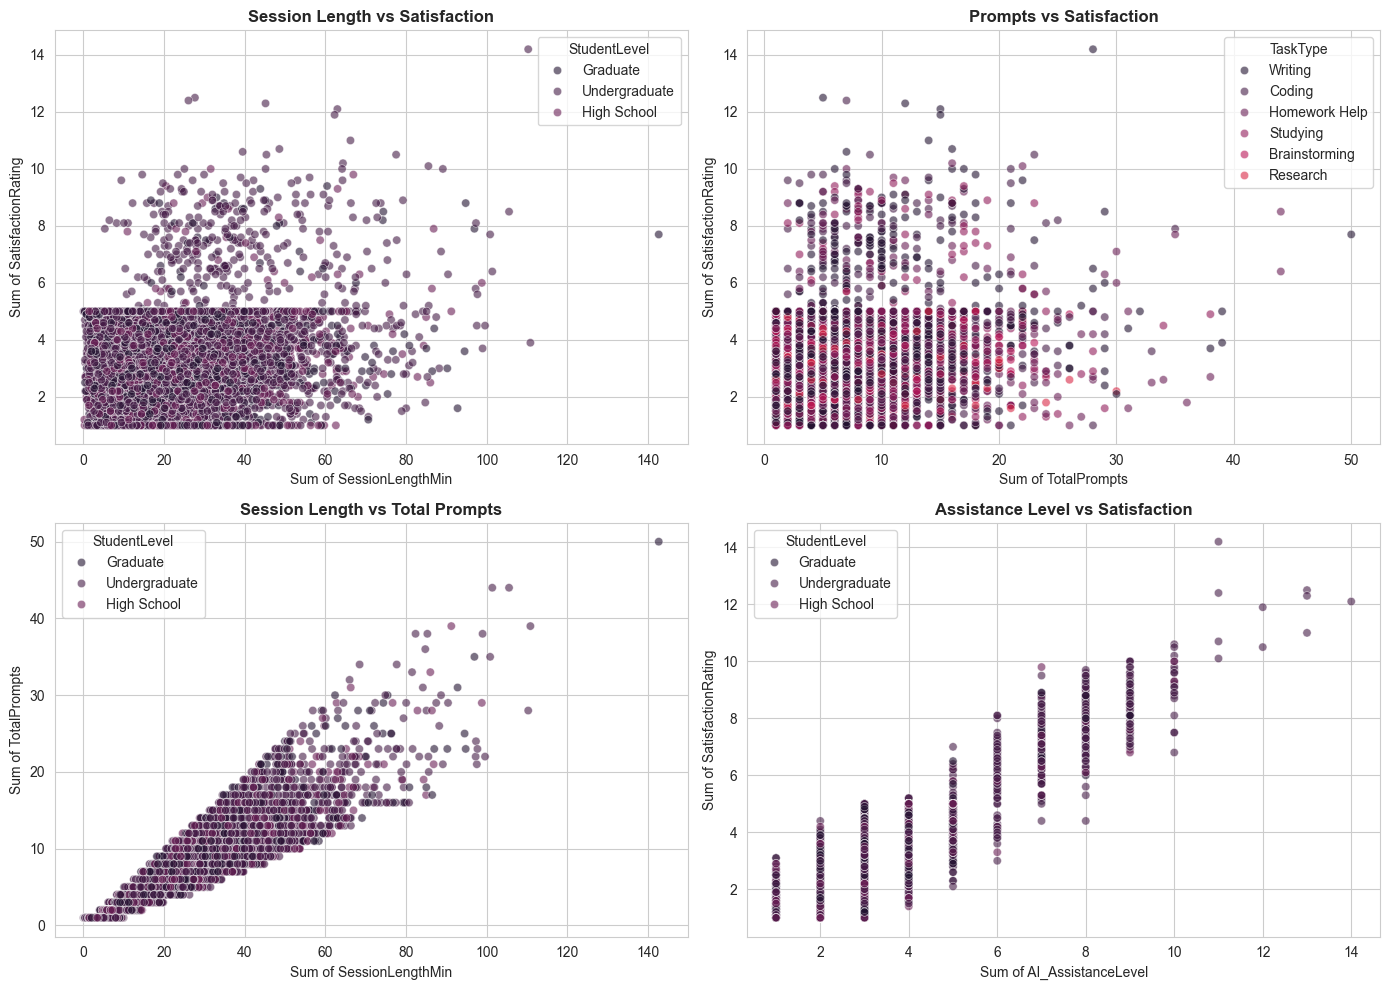

In [30]:
# Scatter relationships among key quantitative features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='Sum of SessionLengthMin', y='Sum of SatisfactionRating',
                hue='StudentLevel', ax=axes[0, 0], alpha=0.6, palette=palette_discrete)
axes[0, 0].set_title('Session Length vs Satisfaction', fontsize=12, fontweight='bold')

sns.scatterplot(data=df, x='Sum of TotalPrompts', y='Sum of SatisfactionRating',
                hue='TaskType', ax=axes[0, 1], alpha=0.6, palette=palette_discrete)
axes[0, 1].set_title('Prompts vs Satisfaction', fontsize=12, fontweight='bold')

sns.scatterplot(data=df, x='Sum of SessionLengthMin', y='Sum of TotalPrompts',
                hue='StudentLevel', ax=axes[1, 0], alpha=0.6, palette=palette_discrete)
axes[1, 0].set_title('Session Length vs Total Prompts', fontsize=12, fontweight='bold')

sns.scatterplot(data=df, x='Sum of AI_AssistanceLevel', y='Sum of SatisfactionRating',
                hue='StudentLevel', ax=axes[1, 1], alpha=0.6, palette=palette_discrete)
axes[1, 1].set_title('Assistance Level vs Satisfaction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Relationship Notes
Satisfaction appears only mildly linked with time on task or prompt volume, while higher assistance levels cluster with students requesting more prompts—signaling deeper support needs rather than guaranteed satisfaction boosts.

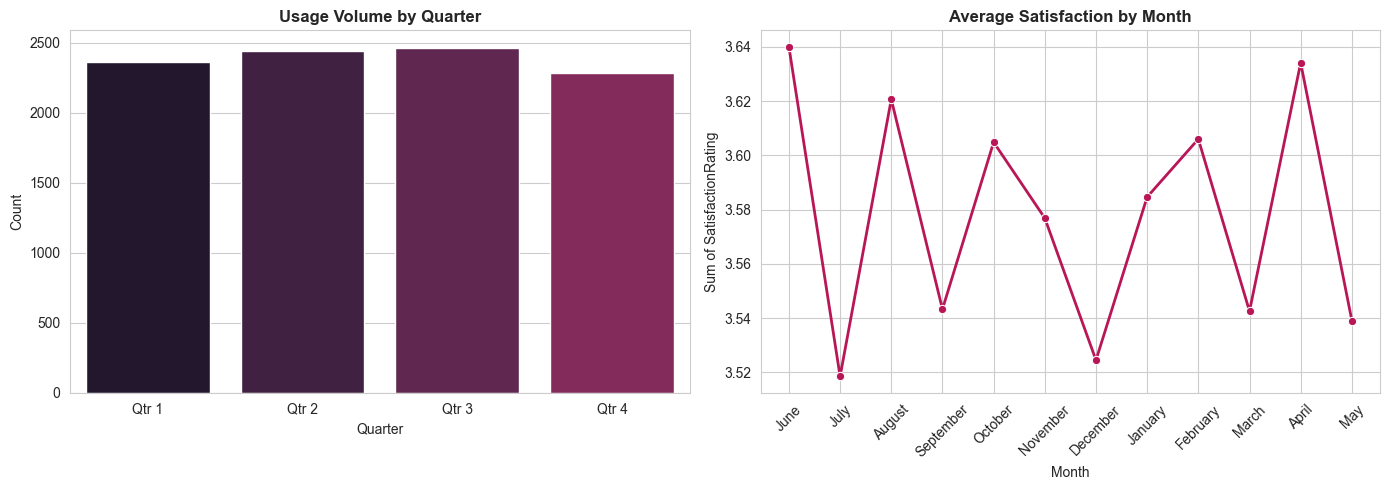

Quarter-Level Averages:
         Sum of SatisfactionRating  Sum of SessionLengthMin  \
Quarter                                                       
Qtr 1                         3.58                    20.90   
Qtr 2                         3.60                    20.75   
Qtr 3                         3.56                    20.66   
Qtr 4                         3.57                    20.82   

         Sum of TotalPrompts  
Quarter                       
Qtr 1                   5.92  
Qtr 2                   5.89  
Qtr 3                   5.85  
Qtr 4                   5.82  


In [31]:
# Temporal usage trends by quarter and month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quarter_summary = df.groupby('Quarter').agg({
    'Sum of SatisfactionRating': 'mean',
    'Sum of SessionLengthMin': 'mean',
    'Sum of TotalPrompts': 'mean',
}).round(2)

sns.barplot(data=df.groupby('Quarter').size().reset_index(name='Count'),
            x='Quarter', y='Count', ax=axes[0], palette=palette_discrete)
axes[0].set_title('Usage Volume by Quarter', fontsize=12, fontweight='bold')

month_order = ['June', 'July', 'August', 'September', 'October', 'November', 'December',
               'January', 'February', 'March', 'April', 'May']
df_month = df.copy()
df_month['Month'] = pd.Categorical(df_month['Month'], categories=month_order, ordered=True)
df_month = df_month.sort_values('Month')

sns.lineplot(data=df_month.groupby('Month')['Sum of SatisfactionRating'].mean().reset_index(),
             x='Month', y='Sum of SatisfactionRating', marker='o', ax=axes[1],
             color=palette_discrete[4], linewidth=2)
axes[1].set_title('Average Satisfaction by Month', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Quarter-Level Averages:')
print(quarter_summary)

## Temporal Dynamics
Track engagement volume and satisfaction over time to flag seasonal spikes or drop-offs in AI reliance.

## Repeat Usage Behaviour
Determine which students come back to the AI assistant and how satisfaction aligns with repeat adoption.

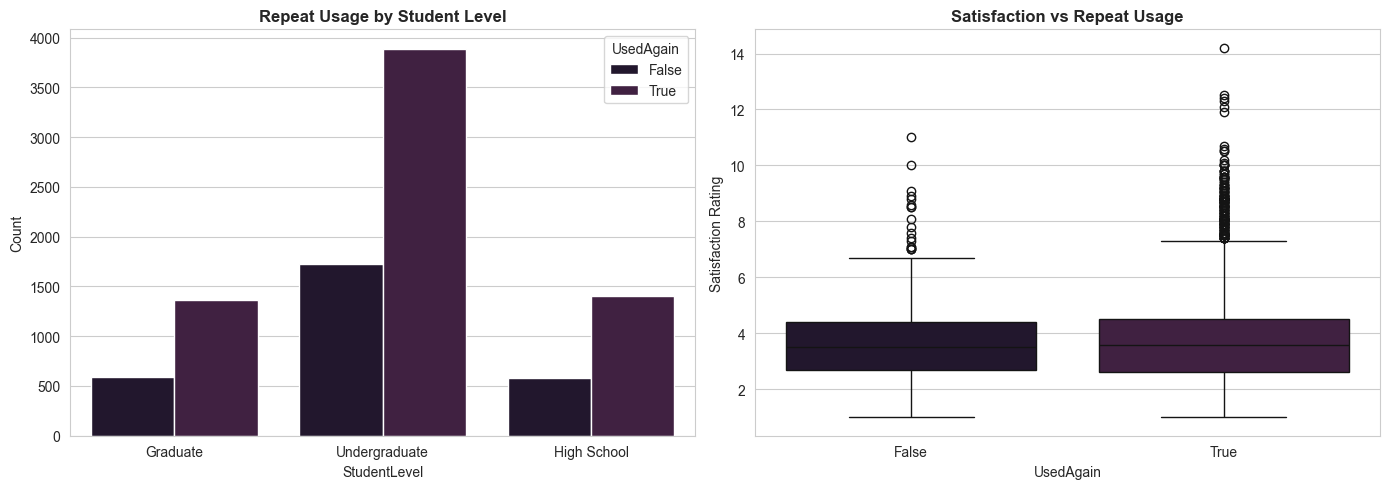

Repeat usage rate: 69.7%

Satisfaction by repeat usage flag:
               mean       std  count
UsedAgain                           
False      3.485413  1.198995   2893
True       3.618880  1.470382   6658

Repeat usage by task type:
UsedAgain      False  True   All
TaskType                        
Brainstorming    145   329   474
Coding           495  1370  1865
Homework Help    601  1271  1872
Research         170   305   475
Studying         640  1333  1973
Writing          842  2050  2892
All             2893  6658  9551


In [32]:
# Examine re-usage behaviour across segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='StudentLevel', hue='UsedAgain', ax=axes[0], palette=palette_discrete)
axes[0].set_title('Repeat Usage by Student Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='UsedAgain', y='Sum of SatisfactionRating', ax=axes[1], palette=palette_discrete)
axes[1].set_title('Satisfaction vs Repeat Usage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Satisfaction Rating')

plt.tight_layout()
plt.show()

reuse_rate = (df['UsedAgain'] == True).mean() * 100
print(f'Repeat usage rate: {reuse_rate:.1f}%')
print('\nSatisfaction by repeat usage flag:')
print(df.groupby('UsedAgain')['Sum of SatisfactionRating'].agg(['mean', 'std', 'count']))

print('\nRepeat usage by task type:')
print(pd.crosstab(df['TaskType'], df['UsedAgain'], margins=True))

### Repeat Usage Notes
Graduate and undergraduate students are the most frequent repeat adopters, and satisfaction tends to sit slightly higher for return users, reinforcing a positive usage loop.

## Key Insights Summary
Condense the main narrative threads to inform next analytical or strategic steps.

In [33]:
# Summarize high-level insights extracted above
print('=' * 70)
print('KEY INSIGHTS FROM STUDENT AI CONSUMPTION DATA')
print('=' * 70)

print('\n1. PARTICIPATION LANDSCAPE:')
print(f"   • Records analysed: {len(df):,}")
print(f"   • Disciplines covered: {df['Discipline'].nunique()} ({', '.join(sorted(df['Discipline'].unique()))})")
print(f"   • Academic levels: {df['StudentLevel'].nunique()} ({', '.join(sorted(df['StudentLevel'].unique()))})")
print(f"   • Task variety: {df['TaskType'].nunique()} unique task types")

print('\n2. SATISFACTION PATTERNS:')
print(f"   • Overall average satisfaction: {df['Sum of SatisfactionRating'].mean():.2f}/10")
print(f"   • Highest satisfaction task type: {df.groupby('TaskType')['Sum of SatisfactionRating'].mean().idxmax()}")
print(f"   • Highest satisfaction student level: {df.groupby('StudentLevel')['Sum of SatisfactionRating'].mean().idxmax()}")

print('\n3. ENGAGEMENT INTENSITY:')
print(f"   • Average session length: {df['Sum of SessionLengthMin'].mean():.2f} minutes")
print(f"   • Average prompts per session: {df['Sum of TotalPrompts'].mean():.2f}")
print(f"   • Average AI assistance level: {df['Sum of AI_AssistanceLevel'].mean():.2f}")

print('\n4. REPEAT USAGE:')
reuse_pct = (df['UsedAgain'] == True).mean() * 100
print(f"   • Students returning to AI: {reuse_pct:.1f}%")
print(f"   • Satisfaction (repeat users): {df[df['UsedAgain'] == True]['Sum of SatisfactionRating'].mean():.2f}")
print(f"   • Satisfaction (non-repeat users): {df[df['UsedAgain'] == False]['Sum of SatisfactionRating'].mean():.2f}")

print('\n5. KEY CORRELATIONS:')
print(f"   • Session length vs satisfaction: {df['Sum of SessionLengthMin'].corr(df['Sum of SatisfactionRating']):.3f}")
print(f"   • Prompts vs satisfaction: {df['Sum of TotalPrompts'].corr(df['Sum of SatisfactionRating']):.3f}")
print(f"   • Assistance vs satisfaction: {df['Sum of AI_AssistanceLevel'].corr(df['Sum of SatisfactionRating']):.3f}")

print('\n6. TASK POPULARITY:')
task_counts = df['TaskType'].value_counts()
print(f"   • Most common task: {task_counts.idxmax()} ({task_counts.max()} records)")
print(f"   • Least common task: {task_counts.idxmin()} ({task_counts.min()} records)")

print('=' * 70)

KEY INSIGHTS FROM STUDENT AI CONSUMPTION DATA

1. PARTICIPATION LANDSCAPE:
   • Records analysed: 9,551
   • Disciplines covered: 7 (Biology, Business, Computer Science, Engineering, History, Math, Psychology)
   • Academic levels: 3 (Graduate, High School, Undergraduate)
   • Task variety: 6 unique task types

2. SATISFACTION PATTERNS:
   • Overall average satisfaction: 3.58/10
   • Highest satisfaction task type: Writing
   • Highest satisfaction student level: Undergraduate

3. ENGAGEMENT INTENSITY:
   • Average session length: 20.78 minutes
   • Average prompts per session: 5.87
   • Average AI assistance level: 3.64

4. REPEAT USAGE:
   • Students returning to AI: 69.7%
   • Satisfaction (repeat users): 3.62
   • Satisfaction (non-repeat users): 3.49

5. KEY CORRELATIONS:
   • Session length vs satisfaction: 0.150
   • Prompts vs satisfaction: 0.117
   • Assistance vs satisfaction: 0.848

6. TASK POPULARITY:
   • Most common task: Writing (2892 records)
   • Least common task: Bra